### IMPORTS

In [13]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem.snowball import FrenchStemmer
from collections import Counter

nltk.download('stopwords', quiet=True)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay ,classification_report
)
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from gensim.models import Word2Vec, FastText

# Style global
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

from sentence_transformers import SentenceTransformer


### LOAD DATA

In [14]:
df_clean = pd.read_csv("../data/df_clean.csv")

text_col = "Rapport_Collecte"
target   = "Categorie"

X = df_clean[text_col].astype(str)
y = df_clean[target]

print(f"Dimensions : {df_clean.shape[0]} lignes x {df_clean.shape[1]} colonnes")

Dimensions : 9724 lignes x 9 colonnes


### SPLIT

In [15]:
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=42, stratify=y_tmp
)

print(X_train.shape, X_val.shape, X_test.shape)

(6806,) (1459,) (1459,)


### PRÉTRAITEMENT TEXTUEL

Pipeline : normalisation → tokenisation → suppression des stopwords (français + domaine) → stemming (FrenchStemmer)

In [16]:
# ─── STOPWORDS FRANÇAIS (NLTK) ───────────────────────────────────────────────
STOPWORDS_FR = set(stopwords.words("french"))


STOPWORDS_DOMAINE = {

    # administratif
    "rapport","collecte","observation","note","constat",
    "visite","lot","provenance","provenant","issu","origine",

    # lieux
    "site","zone","secteur","centre","usine","municipal",
    "localisation","emplacement",

    # organisation
    "agent","équipe","general","général",

    # qualité
    "standard","standards","conforme",
    "verification","vérification",
    "recommandee","recommandée",
    "prioritaire",

    # mesures déjà présentes en colonnes numériques
    "poids","volume","masse","kg","l",
    "mesuré","mesure","estimé","estime",

    # intensité inutile
    "très","extremement","extrêmement",
    "moyen","moyenne","faible","élevée",

    # mots vides dataset
    "non","aucune","aucun","sans"
}

STOPWORDS_TOUS = STOPWORDS_FR | STOPWORDS_DOMAINE

stemmer = FrenchStemmer()


def preprocess(text: str) -> str:
    """
    Pipeline NLP :
    1. Mise en minuscules
    2. Suppression des caractères non-alphabétiques (garde accents français)
    3. Tokenisation par split
    4. Suppression des stopwords FR + domaine (version corrigée)
    5. Suppression des tokens ≤ 2 caractères
    6. Stemming FrenchStemmer (NLTK Snowball)
    Retourne une chaîne de tokens traités rejoints par espaces.
    """
    text = text.lower()
    text = re.sub(r"[^a-zàâäéèêëîïôùûüç\s]", " ", text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOPWORDS_TOUS and len(t) > 2]
    tokens = [stemmer.stem(t) for t in tokens]
    return " ".join(tokens)


# Application sur les trois partitions
X_train_clean = X_train.apply(preprocess)
X_val_clean   = X_val.apply(preprocess)
X_test_clean  = X_test.apply(preprocess)

# Vérification rapide
print("Avant :", X_train.iloc[0])
print("Après :", X_train_clean.iloc[0])
print(f"\nVocabulaire train : {len(set(' '.join(X_train_clean).split()))} tokens uniques")

Avant : Lot de verre trié en provenance de l'Usine A. Masse 185.6 kg. Matériau lourd et extrêmement rigide. Aspect indéterminée. Étiquetage absent sur le conteneur.
Après : verr tri matériau lourd rigid aspect indétermin étiquetag absent conteneur

Vocabulaire train : 116 tokens uniques


### Configuration des Modèles et MLflow

In [17]:

import mlflow

mlflow.set_tracking_uri("sqlite:///mlflow.db")
exp = mlflow.set_experiment("EcoSmart_NLP_Vectorisation")

print(" MLflow experiment initialisé")

models_text = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Linear SVC": LinearSVC(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

models_emb = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Linear SVC": LinearSVC(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

def evaluate(model, Xtr, Xte, ytr, yte,
             representation="unknown",
             model_name="unknown",
             log_mlflow=True):

    model.fit(Xtr, ytr)
    pred = model.predict(Xte)

    acc  = accuracy_score(yte, pred)
    prec = precision_score(yte, pred, average="weighted", zero_division=0)
    rec  = recall_score(yte, pred, average="weighted", zero_division=0)
    f1   = f1_score(yte, pred, average="weighted", zero_division=0)

    if log_mlflow:
        with mlflow.start_run(experiment_id=exp.experiment_id, run_name=f"{representation}_{model_name}"):
            mlflow.set_tag("representation", representation, )
            mlflow.set_tag("model_name", model_name, )
            mlflow.set_tag("dataset", "EcoSmart")
            mlflow.set_tag("task", "text_classification")

            mlflow.log_metric("accuracy", acc)
            mlflow.log_metric("precision", prec)
            mlflow.log_metric("recall", rec)
            mlflow.log_metric("f1", f1)

    return acc, prec, rec, f1

 MLflow experiment initialisé


### BAG OF WORDS (BASELINE)

In [32]:
print("\n=== BAG OF WORDS ===")

bow = CountVectorizer()

X_train_bow = bow.fit_transform(X_train_clean)
X_test_bow  = bow.transform(X_test_clean)

results_bow = {}

for name, model in models_text.items():
    acc, prec, rec, f1 = evaluate(model, X_train_bow, X_test_bow, y_train, y_test, representation="BoW", model_name=name)

    print(f"\n=== {name} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    results_bow[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1-score": f1}


=== BAG OF WORDS ===

=== Naive Bayes ===
Accuracy : 0.9650
Precision: 0.9666
Recall   : 0.9650
F1-score : 0.9653

=== Logistic Regression ===
Accuracy : 0.9623
Precision: 0.9635
Recall   : 0.9623
F1-score : 0.9625

=== Linear SVC ===
Accuracy : 0.9623
Precision: 0.9635
Recall   : 0.9623
F1-score : 0.9625

=== Random Forest ===
Accuracy : 0.9644
Precision: 0.9647
Recall   : 0.9644
F1-score : 0.9644


#### Matrice de Confusion — Meilleur modèle bag of word

 Meilleur modèle BoW : Naive Bayes (F1=0.9653)


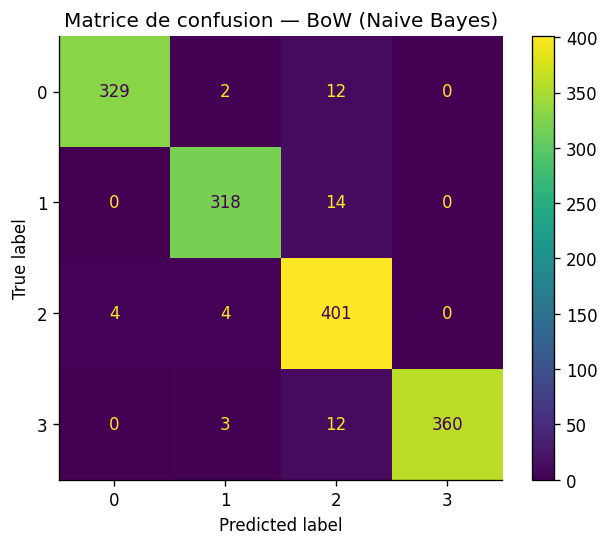


=== Classification Report ===
              precision    recall  f1-score   support

           0       0.99      0.96      0.97       343
           1       0.97      0.96      0.97       332
           2       0.91      0.98      0.95       409
           3       1.00      0.96      0.98       375

    accuracy                           0.97      1459
   macro avg       0.97      0.96      0.97      1459
weighted avg       0.97      0.97      0.97      1459



In [ ]:
# MEILLEUR MODÈLE BOw
best_model_name = max(results_bow, key=lambda x: results_bow[x]["F1-score"])

print(" Meilleur modèle BoW :", best_model_name,
      f"(F1={results_bow[best_model_name]['F1-score']:.4f})")

best_model = models_text[best_model_name]
best_model.fit(X_train_bow, y_train)
y_pred_best = best_model.predict(X_test_bow)

# MATRICE DE CONFUSION
cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title(f"Matrice de confusion — BoW ({best_model_name})")
plt.show()

# CLASSIFICATION REPORT
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_best))

### TF-IDF (REFERENCE)

In [7]:
print("\n=== TF-IDF ===")

tfidf = TfidfVectorizer(ngram_range=(1, 2))

X_train_tfidf = tfidf.fit_transform(X_train_clean)
X_test_tfidf  = tfidf.transform(X_test_clean)

results_tfidf = {}

for name, model in models_text.items():
    acc, prec, rec, f1 = evaluate(model, X_train_tfidf, X_test_tfidf, y_train, y_test, representation="TF-IDF", model_name=name)

    print(f"\n=== {name} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    results_tfidf[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1-score": f1}


=== TF-IDF ===

=== Naive Bayes ===
Accuracy : 0.9616
Precision: 0.9634
Recall   : 0.9616
F1-score : 0.9619

=== Logistic Regression ===
Accuracy : 0.9630
Precision: 0.9656
Recall   : 0.9630
F1-score : 0.9635

=== Linear SVC ===
Accuracy : 0.9637
Precision: 0.9644
Recall   : 0.9637
F1-score : 0.9638

=== Random Forest ===
Accuracy : 0.9650
Precision: 0.9655
Recall   : 0.9650
F1-score : 0.9651


#### Matrice de Confusion — Meilleur modèle TF-IDF


Meilleur modèle TF-IDF : Random Forest avec F1-score=0.9651


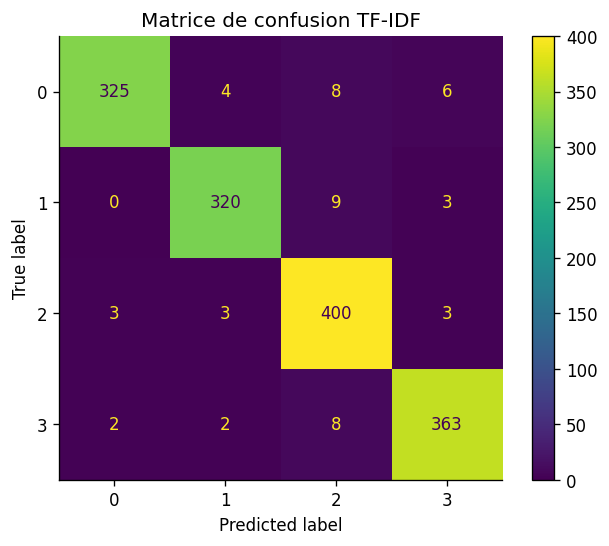


=== Classification Report ===
              precision    recall  f1-score   support

           0       0.98      0.95      0.97       343
           1       0.97      0.96      0.97       332
           2       0.94      0.98      0.96       409
           3       0.97      0.97      0.97       375

    accuracy                           0.97      1459
   macro avg       0.97      0.96      0.97      1459
weighted avg       0.97      0.97      0.97      1459



In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# meilleur modèle
best_model_name = max(results_tfidf, key=lambda x: results_tfidf[x]["F1-score"])
print("\nMeilleur modèle TF-IDF :", best_model_name , f"avec F1-score={results_tfidf[best_model_name]['F1-score']:.4f}")

best_model = models_text[best_model_name]
best_model.fit(X_train_tfidf, y_train)

y_pred = best_model.predict(X_test_tfidf)

# matrice
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot()

plt.title("Matrice de confusion TF-IDF")
plt.show()

# rapport
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

### WORD2VEC (SÉMANTIQUE)

In [28]:
# Tokenisation sur les textes prétraités
sentences = [text.split() for text in X_train_clean]

w2v = Word2Vec(sentences, vector_size=100, window=5, min_count=2, workers=4)


def vectorize_w2v(text: str) -> np.ndarray:
    words = text.split()
    vecs  = [w2v.wv[w] for w in words if w in w2v.wv]
    if not vecs:
        return np.zeros(100)
    return np.mean(vecs, axis=0)


X_train_w2v = np.vstack([vectorize_w2v(t) for t in X_train_clean]).astype(np.float32)
X_test_w2v  = np.vstack([vectorize_w2v(t) for t in X_test_clean]).astype(np.float32)

results_w2v = {}

for name, model in models_emb.items():
    acc, prec, rec, f1 = evaluate(model, X_train_w2v, X_test_w2v, y_train, y_test, representation="Word2Vec", model_name=name)

    print(f"\n=== {name} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    results_w2v[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1-score": f1}


=== Logistic Regression ===
Accuracy : 0.9630
Precision: 0.9646
Recall   : 0.9630
F1-score : 0.9633

=== Linear SVC ===
Accuracy : 0.9609
Precision: 0.9633
Recall   : 0.9609
F1-score : 0.9613

=== Random Forest ===
Accuracy : 0.9671
Precision: 0.9675
Recall   : 0.9671
F1-score : 0.9671


#### Matrice de confusion word2VEC meilleur modéle

Meilleur modèle Word2Vec : Random Forest (F1=0.9671)


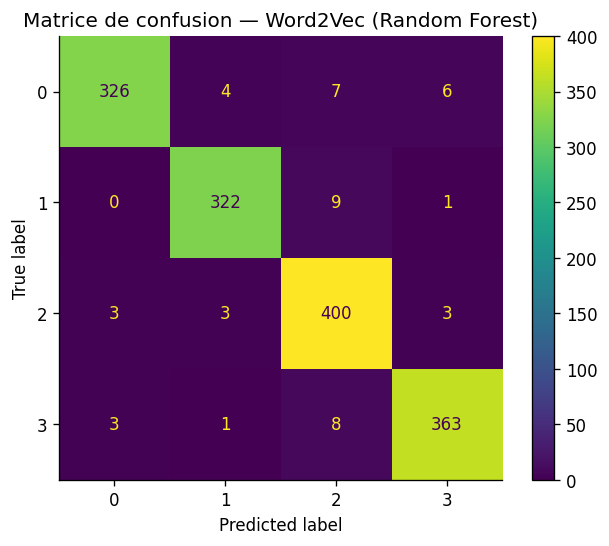


=== Classification Report ===
              precision    recall  f1-score   support

           0       0.98      0.95      0.97       343
           1       0.98      0.97      0.97       332
           2       0.94      0.98      0.96       409
           3       0.97      0.97      0.97       375

    accuracy                           0.97      1459
   macro avg       0.97      0.97      0.97      1459
weighted avg       0.97      0.97      0.97      1459



In [29]:

# MEILLEUR MODÈLE WORD2VEC
best_model_name = max(results_w2v, key=lambda x: results_w2v[x]["F1-score"])

print("Meilleur modèle Word2Vec :", best_model_name,
      f"(F1={results_w2v[best_model_name]['F1-score']:.4f})")

best_model = models_emb[best_model_name]
best_model.fit(X_train_w2v, y_train)
y_pred_best = best_model.predict(X_test_w2v)

# MATRICE DE CONFUSION
cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title(f"Matrice de confusion — Word2Vec ({best_model_name})")
plt.show()

# CLASSIFICATION REPORT
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_best))

### FASTTEXT

In [30]:
ft = FastText(sentences, vector_size=100, window=5, min_count=2, workers=4)


def vectorize_ft(text: str) -> np.ndarray:
    words = text.split()
    if not words:
        return np.zeros(100)
    # ft.wv[w] fonctionne même pour les mots OOV (hors vocabulaire)
    # grâce aux n-grammes de caractères — ne pas filtrer avec 'if w in ft.wv'
    vecs = [ft.wv[w] for w in words]
    return np.mean(vecs, axis=0)


X_train_ft = np.vstack([vectorize_ft(t) for t in X_train_clean]).astype(np.float32)
X_test_ft  = np.vstack([vectorize_ft(t) for t in X_test_clean]).astype(np.float32)

results_fasttext = {}

for name, model in models_emb.items():
    acc, prec, rec, f1 = evaluate(model, X_train_ft, X_test_ft, y_train, y_test, representation="FastText", model_name=name)

    print(f"\n=== {name} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    results_fasttext[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1-score": f1}


=== Logistic Regression ===
Accuracy : 0.9630
Precision: 0.9635
Recall   : 0.9630
F1-score : 0.9631

=== Linear SVC ===
Accuracy : 0.9637
Precision: 0.9653
Recall   : 0.9637
F1-score : 0.9640

=== Random Forest ===
Accuracy : 0.9664
Precision: 0.9668
Recall   : 0.9664
F1-score : 0.9664


####  Matrice de Confusion — Meilleur modèle FASTTEXT

✅ Meilleur modèle FastText : Random Forest (F1=0.9664)


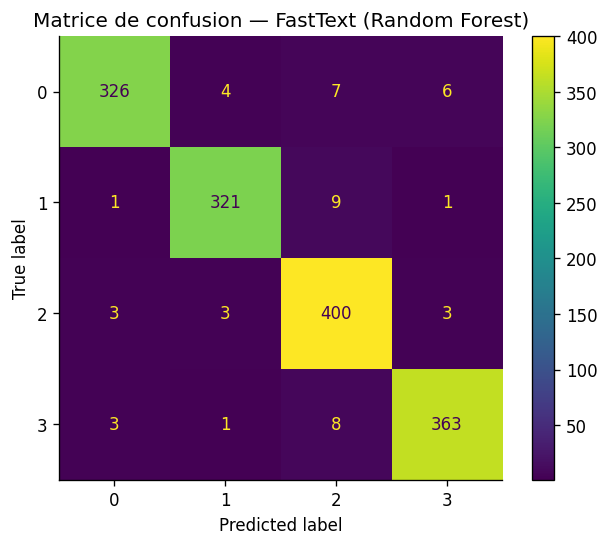


=== Classification Report ===
              precision    recall  f1-score   support

           0       0.98      0.95      0.96       343
           1       0.98      0.97      0.97       332
           2       0.94      0.98      0.96       409
           3       0.97      0.97      0.97       375

    accuracy                           0.97      1459
   macro avg       0.97      0.97      0.97      1459
weighted avg       0.97      0.97      0.97      1459



In [ ]:
# MEILLEUR MODÈLE FASTTEXT
best_model_name = max(results_fasttext, key=lambda x: results_fasttext[x]["F1-score"])

print(" Meilleur modèle FastText :", best_model_name,
      f"(F1={results_fasttext[best_model_name]['F1-score']:.4f})")

best_model = models_emb[best_model_name]
best_model.fit(X_train_ft, y_train)
y_pred_best = best_model.predict(X_test_ft)

# MATRICE DE CONFUSION
cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title(f"Matrice de confusion — FastText ({best_model_name})")
plt.show()

# CLASSIFICATION REPORT
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_best))

### CAMEMBERT (BONUS — Sentence Transformers)

In [10]:

from sentence_transformers import SentenceTransformer
model_cam = SentenceTransformer("dangvantuan/sentence-camembert-base")

X_train_cam = model_cam.encode(X_train.tolist(), show_progress_bar=True)
X_test_cam  = model_cam.encode(X_test.tolist(),  show_progress_bar=True)

results_cam = {}

for name, model in models_emb.items():
    acc, prec, rec, f1 = evaluate(model, X_train_cam, X_test_cam, y_train, y_test, representation="CamemBERT", model_name=name)

    print(f"\n=== {name} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    results_cam[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1-score": f1}

Batches: 100%|██████████| 46/46 [00:32<00:00,  1.43it/s]



=== Logistic Regression ===
Accuracy : 0.9815
Precision: 0.9818
Recall   : 0.9815
F1-score : 0.9815

=== Linear SVC ===
Accuracy : 0.9842
Precision: 0.9845
Recall   : 0.9842
F1-score : 0.9843

=== Random Forest ===
Accuracy : 0.9705
Precision: 0.9719
Recall   : 0.9705
F1-score : 0.9707


#### Matrice de Confusion — Meilleur modèle CAMEMBERT


 Meilleur modèle CamemBERT : Linear SVC (F1=0.9843)


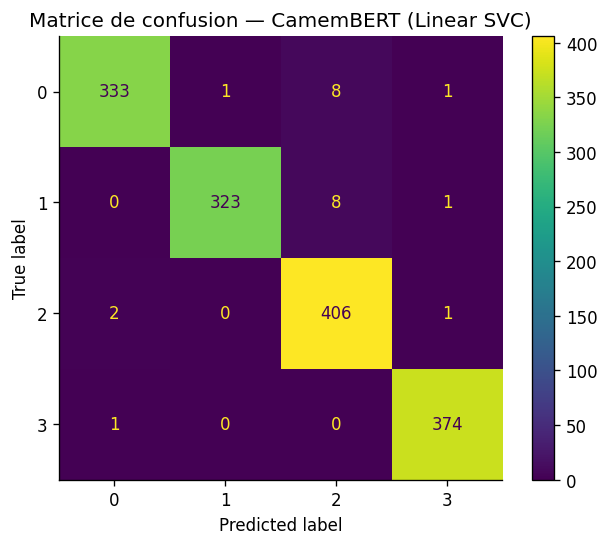


=== Classification Report (CamemBERT) ===
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       343
           1       1.00      0.97      0.98       332
           2       0.96      0.99      0.98       409
           3       0.99      1.00      0.99       375

    accuracy                           0.98      1459
   macro avg       0.99      0.98      0.98      1459
weighted avg       0.98      0.98      0.98      1459



In [39]:

best_model_name_cam = max(results_cam, key=lambda x: results_cam[x]["F1-score"])

print("\n Meilleur modèle CamemBERT :", best_model_name_cam,
      f"(F1={results_cam[best_model_name_cam]['F1-score']:.4f})")

best_model_cam = models_emb[best_model_name_cam]

# IMPORTANT : ré-entrainer sur tout le train
best_model_cam.fit(X_train_cam, y_train)

y_pred_best_cam = best_model_cam.predict(X_test_cam)

# MATRICE DE CONFUSION
cm_cam = confusion_matrix(y_test, y_pred_best_cam)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_cam)
disp.plot()

plt.title(f"Matrice de confusion — CamemBERT ({best_model_name_cam})")
plt.show()

print("\n=== Classification Report (CamemBERT) ===")
print(classification_report(y_test, y_pred_best_cam))

### TABLEAU COMPARATIF

In [40]:
NAN = float('nan')

index_order = ['Linear SVC', 'Logistic Regression', 'Random Forest', 'Naive Bayes']

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']

def build_metric_df(metric):
    return pd.DataFrame(
        {
            'BoW': [
                results_bow['Linear SVC'][metric],
                results_bow['Logistic Regression'][metric],
                results_bow['Random Forest'][metric],
                results_bow['Naive Bayes'][metric],
            ],
            'TF-IDF': [
                results_tfidf['Linear SVC'][metric],
                results_tfidf['Logistic Regression'][metric],
                results_tfidf['Random Forest'][metric],
                results_tfidf['Naive Bayes'][metric],
            ],
            'Word2Vec': [
                results_w2v['Linear SVC'][metric],
                results_w2v['Logistic Regression'][metric],
                results_w2v['Random Forest'][metric],
                NAN,  # MultinomialNB incompatible avec embeddings denses
            ],
            'FastText': [
                results_fasttext['Linear SVC'][metric],
                results_fasttext['Logistic Regression'][metric],
                results_fasttext['Random Forest'][metric],
                NAN,  # MultinomialNB incompatible avec embeddings denses
            ],
            'CamemBERT': [
                results_cam['Linear SVC'][metric],
                results_cam['Logistic Regression'][metric],
                results_cam['Random Forest'][metric],
                NAN,  # MultinomialNB incompatible avec embeddings denses
            ],
        },
        index=index_order
    ).round(4)

results_all = {metric: build_metric_df(metric) for metric in metrics}

for metric, df in results_all.items():
    print(f'\n=== {metric} (test set) ===')
    print(df.to_string())


=== Accuracy (test set) ===
                        BoW  TF-IDF  Word2Vec  FastText  CamemBERT
Linear SVC           0.9623  0.9637    0.9609    0.9637     0.9842
Logistic Regression  0.9623  0.9630    0.9630    0.9630     0.9815
Random Forest        0.9644  0.9650    0.9671    0.9664     0.9705
Naive Bayes          0.9650  0.9616       NaN       NaN        NaN

=== Precision (test set) ===
                        BoW  TF-IDF  Word2Vec  FastText  CamemBERT
Linear SVC           0.9635  0.9644    0.9633    0.9653     0.9845
Logistic Regression  0.9635  0.9656    0.9646    0.9635     0.9818
Random Forest        0.9647  0.9655    0.9675    0.9668     0.9719
Naive Bayes          0.9666  0.9634       NaN       NaN        NaN

=== Recall (test set) ===
                        BoW  TF-IDF  Word2Vec  FastText  CamemBERT
Linear SVC           0.9623  0.9637    0.9609    0.9637     0.9842
Logistic Regression  0.9623  0.9630    0.9630    0.9630     0.9815
Random Forest        0.9644  0.9650    0.96